**CMD + MIST isochrones (ages in Gyr)**


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
→ Plotted 42 stars from Casado-Alessi 1
0.8 Gyr (dm=8.70, E(B-V)=0.694)
1.45 Gyr (dm=8.58, E(B-V)=0.051)
2 Gyr (dm=8.57, E(B-V)=-0.312)
2.5 Gyr (dm=8.12, E(B-V)=-1.095)
2.75 Gyr (dm=8.18, E(B-V)=-1.032)
3 Gyr (dm=8.22, E(B-V)=-1.038)
3.5 Gyr (dm=7.82, E(B-V)=-1.661)


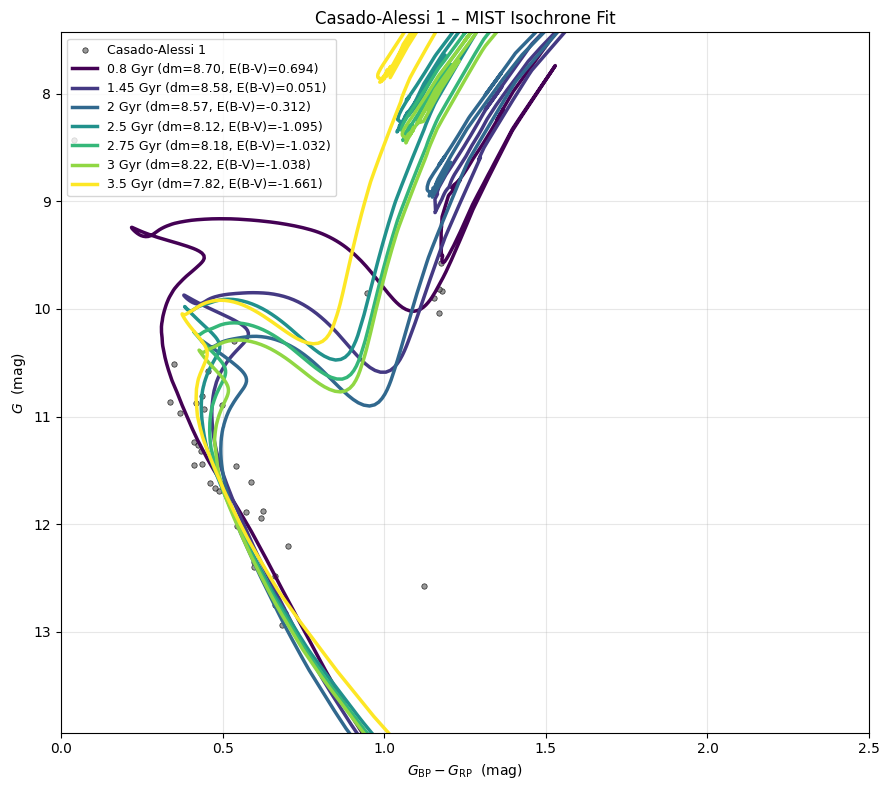

In [7]:
#install if needed 
!pip install -q isochrones  

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from isochrones import get_ichrone
from scipy.optimize import minimize
from scipy.spatial import KDTree

# where is your data located?
STAR_FILE = "final_reordered.csv"
df = pd.read_csv(STAR_FILE, low_memory=False)

def normalize_cluster_name(name):
    return "".join(ch for ch in str(name).lower() if ch.isalnum())

# Find cluster column
cluster_col = next((c for c in df.columns if "cluster" in c.lower()), None)
mask = df[cluster_col].astype(str).map(normalize_cluster_name) == "casadoalessi1"
df_ca1 = df[mask].copy()

# Find Gaia columns
cols = df_ca1.columns.str.lower()
g_col   = df_ca1.columns[cols.str.contains("g_mean_mag|gmag")][0]
bp_col  = df_ca1.columns[cols.str.contains("bp.*mag")][0]
rp_col  = df_ca1.columns[cols.str.contains("rp.*mag")][0]

color_cl = df_ca1[bp_col].values - df_ca1[rp_col].values
g_mag_cl = df_ca1[g_col].values
good = np.isfinite(color_cl) & np.isfinite(g_mag_cl)
color_cl = color_cl[good]
g_mag_cl = g_mag_cl[good]

print(f"→ Plotted {len(color_cl)} stars from Casado-Alessi 1")

# isochrones
mist = get_ichrone('mist', bands=['G', 'BP', 'RP'])   

# Approximate Gaia extinction coefficients 
A_G  = 2.74 * 0.1      
A_BP = 3.37 * 0.1
A_RP = 2.04 * 0.1

# Loss function
def cmd_distance(params, iso):
    dm, ebv = params
    col_pred = (iso['BP_mag'] - iso['RP_mag']) + (A_BP - A_RP) * ebv
    mag_pred = iso['G_mag'] + dm + A_G * ebv
    points   = np.column_stack((col_pred, mag_pred))
    tree     = KDTree(points)
    dist, _  = tree.query(np.column_stack((color_cl, g_mag_cl)))
    return np.sum(dist)

#Ages you want (in Gyr)
ages_gyr = [0.8, 1.45, 2, 2.5, 2.75, 3, 3.5]      # change these however you like!
feh = -0.01                              

# plot
plt.figure(figsize=(9, 8))
plt.scatter(color_cl, g_mag_cl, s=15, color='gray', edgecolors='k', linewidth=0.5, alpha=0.8, label='Casado-Alessi 1')

colors = plt.cm.viridis(np.linspace(0, 1, len(ages_gyr)))

for i, age_gyr in enumerate(ages_gyr):
    logage = np.log10(age_gyr * 1e9)             
    
    iso = mist.isochrone(logage, feh)       
    
    # Fit distance + reddening
    res = minimize(cmd_distance, x0=[10.0, 0.05], args=(iso,), method='Nelder-Mead', tol=1e-3)
    dm_fit, ebv_fit = res.x
    
    # Apply best-fit shift
    col_fit = (iso['BP_mag'] - iso['RP_mag']) + (A_BP - A_RP) * ebv_fit
    mag_fit = iso['G_mag'] + dm_fit + A_G * ebv_fit
    
    label = f"{age_gyr} Gyr (dm={dm_fit:.2f}, E(B-V)={ebv_fit:.3f})"
    plt.plot(col_fit, mag_fit, color=colors[i], lw=2.5, label=label)
    
    print(label)

plt.gca().invert_yaxis()
plt.xlim(0.0, 2.5)
plt.ylim(max(g_mag_cl)+1, min(g_mag_cl)-1)
plt.xlabel(r'$G_{\rm BP} - G_{\rm RP}$  (mag)')
plt.ylabel(r'$G$  (mag)')
plt.title('Casado-Alessi 1 – MIST Isochrone Fit')
plt.legend(fontsize=9, loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()